### Task 1: Designing a Heuristic for a Warehouse Robot

In [1]:
import math
import networkx as nx
import matplotlib.pyplot as plt


# 1. Coordinates of warehouse locations
locations = {
    "Receiving_Area": (0, 0),
    "Storage_A": (2, 1),
    "Storage_B": (1, 4),
    "Sorting_Area": (4, 2),
    "Inspection_Area": (5, 5),
    "Packing_Station": (7, 6),
}


# 2. Weighted warehouse graph
warehouse_graph = {
    "Receiving_Area": {
        "Storage_A": 2.2,
        "Storage_B": 4.1,
    },
    "Storage_A": {
        "Sorting_Area": 2.2,
    },
    "Storage_B": {
        "Inspection_Area": 5.0,
        "Sorting_Area": 6.0,
    },
    "Sorting_Area": {
        "Inspection_Area": 3.2,
        "Packing_Station": 5.0,
    },
    "Inspection_Area": {
        "Packing_Station": 2.2,
    },
    "Packing_Station": {},
}


# 3. Euclidean heuristic
def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.hypot(x2 - x1, y2 - y1)


# 4. Calculate heuristic values
goal = "Packing_Station"
print("Heuristic Values")
print("----------------")
for location in locations:
    print(f"{location:20s}: {heuristic(location, goal):.2f}")

Heuristic Values
----------------
Receiving_Area      : 9.22
Storage_A           : 7.07
Storage_B           : 6.32
Sorting_Area        : 5.00
Inspection_Area     : 2.24
Packing_Station     : 0.00


#### NetworkX visualization: Since Task 1 does not ask GBFS/A* to find a path, you are supposed highlight the actual minimum-cost path merely for visualization:

In [2]:
# 5. Create NetworkX graph
G = nx.DiGraph()
for node, neighbors in warehouse_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

# 6. Find the actual minimum-cost path for visualization
solution_path = nx.shortest_path(
    G,
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight",
)
solution_cost = nx.shortest_path_length(
    G,
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight",
)

print("Minimum cost path:")
print(" -> ".join(solution_path))
print(f"Total cost: {solution_cost:.2f}")

Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


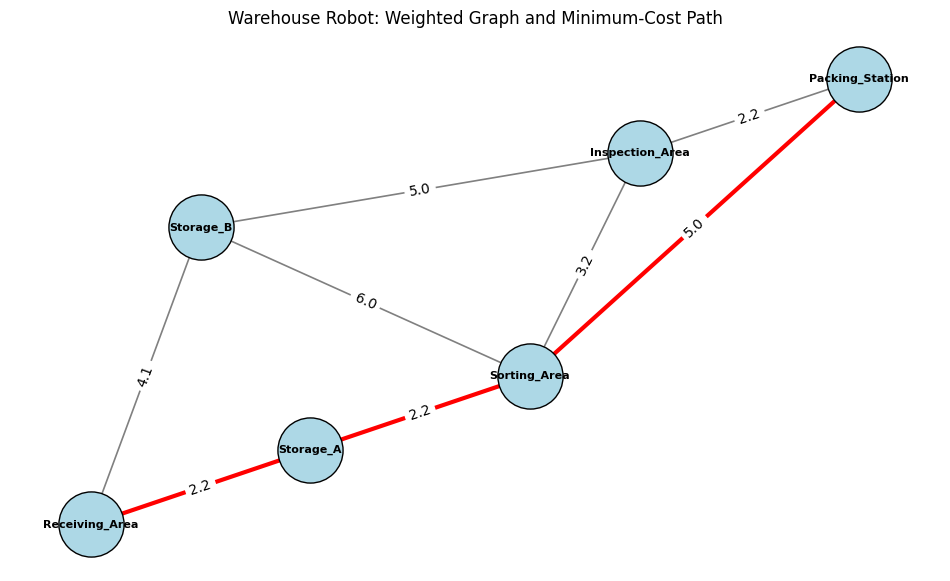

In [3]:
# 7. Visualize graph
pos = locations
path_edges = list(zip(solution_path, solution_path[1:]))
edge_colors = ["red" if edge in path_edges else "gray" for edge in G.edges]
edge_widths = [3 if edge in path_edges else 1.2 for edge in G.edges]

plt.figure(figsize=(12, 7))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=2200, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")
nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    width=edge_widths,
    arrows=True,
    arrowsize=20,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"))
plt.title("Warehouse Robot: Weighted Graph and Minimum-Cost Path")
plt.axis("off")
plt.show()

In [4]:
# 8. Verify heuristic condition
print("\nHeuristic Condition Verification")
print("********************************")
for node in warehouse_graph:
    for neighbor, cost in warehouse_graph[node].items():
        left = heuristic(node, goal)
        right = cost + heuristic(neighbor, goal)
        status = "PASS" if left <= right + 1e-9 else "FAIL"
        print(f"{status}: h({node}) = {left:.2f} <= {cost:.2f} + h({neighbor}) = {right:.2f}")

print("Observation: Euclidean distance is a useful geometric estimate; the rounded edge costs cause any small consistency exception to be visible.")


Heuristic Condition Verification
********************************
PASS: h(Receiving_Area) = 9.22 <= 2.20 + h(Storage_A) = 9.27
PASS: h(Receiving_Area) = 9.22 <= 4.10 + h(Storage_B) = 10.42
PASS: h(Storage_A) = 7.07 <= 2.20 + h(Sorting_Area) = 7.20
PASS: h(Storage_B) = 6.32 <= 5.00 + h(Inspection_Area) = 7.24
PASS: h(Storage_B) = 6.32 <= 6.00 + h(Sorting_Area) = 11.00
PASS: h(Sorting_Area) = 5.00 <= 3.20 + h(Inspection_Area) = 5.44
PASS: h(Sorting_Area) = 5.00 <= 5.00 + h(Packing_Station) = 5.00
FAIL: h(Inspection_Area) = 2.24 <= 2.20 + h(Packing_Station) = 2.20
Observation: Euclidean distance is a useful geometric estimate; the rounded edge costs cause any small consistency exception to be visible.


write down your observation in one line:

### Task 2: Greedy Best-First Search for Airport Baggage Handling

In [5]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt


# 1. Airport coordinates
locations = {
    "Baggage_Area": (0, 0),
    "Security": (2, 1),
    "Checkpoint": (1, 4),
    "Food_Court": (4, 2),
    "Terminal_Hall": (5, 5),
    "Departure_Gate": (7, 6),
}


# 2. Weighted graph
airport_graph = {
    "Baggage_Area": {
        "Security": 2.2,
        "Checkpoint": 4.1,
    },
    "Security": {
        "Food_Court": 2.2,
    },
    "Checkpoint": {
        "Terminal_Hall": 5.0,
    },
    "Food_Court": {
        "Terminal_Hall": 3.2,
        "Departure_Gate": 6.0,
    },
    "Terminal_Hall": {
        "Departure_Gate": 3.2,
    },
    "Departure_Gate": {},
}


# 3. Euclidean heuristic
def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.hypot(x2 - x1, y2 - y1)


# 4. GBFS
def greedy_best_first_search(start, goal, graph):
    frontier = [(heuristic(start, goal), 0, start)]
    came_from = {}
    visited = set()
    expansion_order = []
    counter = 1

    while frontier:
        _, _, current = heapq.heappop(frontier)
        if current in visited:
            continue
        visited.add(current)
        expansion_order.append(current)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            total_cost = sum(
                graph[source][target]
                for source, target in zip(path, path[1:])
            )
            return expansion_order, path, total_cost

        for neighbor in graph[current]:
            if neighbor not in visited:
                came_from.setdefault(neighbor, current)
                heapq.heappush(
                    frontier,
                    (heuristic(neighbor, goal), counter, neighbor),
                )
                counter += 1

    return expansion_order, None, math.inf


# 5. Run GBFS
start = "Baggage_Area"
goal = "Departure_Gate"
expansion_order, path, total_cost = greedy_best_first_search(start, goal, airport_graph)

print("GBFS")
print("--------------------------------")
print("Expansion order:")
print(" -> ".join(expansion_order))
print("\nSolution path:")
print(" -> ".join(path))
print(f"\nTotal path cost: {total_cost:.2f}")
print("GBFS selects the node with the smallest h(n), so it prioritizes locations that appear closest to the Departure Gate.")

GBFS
--------------------------------
Expansion order:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Total path cost: 12.30
GBFS selects the node with the smallest h(n), so it prioritizes locations that appear closest to the Departure Gate.


#### NetworkX visualization

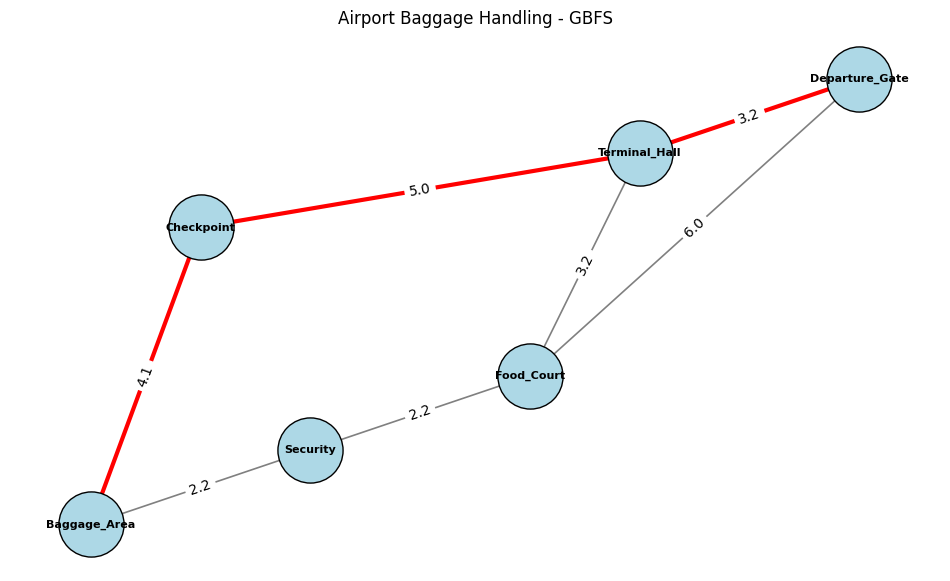

In [6]:
# 6. NetworkX visualization
G = nx.DiGraph()
for node, neighbors in airport_graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

pos = locations
path_edges = list(zip(path, path[1:]))
edge_colors = ["red" if edge in path_edges else "gray" for edge in G.edges]
edge_widths = [3 if edge in path_edges else 1.2 for edge in G.edges]

plt.figure(figsize=(12, 7))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=2200, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")
nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    width=edge_widths,
    arrows=True,
    arrowsize=20,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"))
plt.title("Airport Baggage Handling - GBFS")
plt.axis("off")
plt.show()

### Task 3: A* Search for Emergency Supply Robot

In [7]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd


# 1. Hospital coordinates
locations = {
    "Pharmacy": (0, 0),
    "Main_Corridor": (2, 1),
    "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2),
    "Laboratory": (5, 5),
    "Emergency_Ward": (8, 6),
}


# 2. Hospital weighted graph
hospital_graph = {
    "Pharmacy": {
        "Main_Corridor": 2.2,
        "Patient_Wing": 4.1,
    },
    "Main_Corridor": {
        "Nursing_Station": 2.2,
    },
    "Patient_Wing": {
        "Laboratory": 5.0,
    },
    "Nursing_Station": {
        "Laboratory": 3.2,
        "Emergency_Ward": 5.0,
    },
    "Laboratory": {
        "Emergency_Ward": 3.2,
    },
    "Emergency_Ward": {},
}


# 3. Euclidean heuristic
def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.hypot(x2 - x1, y2 - y1)


# 4. Path reconstruction
def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path


# 5. A* Search
def a_star_search(start, goal, graph):
    frontier = [(heuristic(start, goal), 0, start)]
    came_from = {}
    g_cost = {start: 0.0}
    expansion_order = []
    counter = 1

    while frontier:
        _, _, current = heapq.heappop(frontier)
        if current in expansion_order:
            continue
        expansion_order.append(current)

        if current == goal:
            path = reconstruct_path(came_from, current)
            return expansion_order, path, g_cost[current], g_cost

        for neighbor, cost in graph[current].items():
            tentative_g = g_cost[current] + cost
            if tentative_g < g_cost.get(neighbor, math.inf):
                came_from[neighbor] = current
                g_cost[neighbor] = tentative_g
                f_cost = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(frontier, (f_cost, counter, neighbor))
                counter += 1

    return expansion_order, None, math.inf, g_cost


# 6. Run A*
start = "Pharmacy"
goal = "Emergency_Ward"
expansion_order, path, total_cost, g_cost = a_star_search(start, goal, hospital_graph)

print("A* Search")
print("--------------------------------")
print("Expansion order:")
print(" -> ".join(expansion_order))
print("\nSolution path:")
print(" -> ".join(path))
print(f"\nTotal path cost: {total_cost:.2f}")

A* Search
--------------------------------
Expansion order:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Solution path:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Total path cost: 9.40


#### g(n), h(n), f(n) table

In [8]:
# g(n), h(n), f(n) table
rows = []
for node in expansion_order:
    g_value = g_cost[node]
    h_value = heuristic(node, goal)
    rows.append({
        "Node": node,
        "g(n)": g_value,
        "h(n)": h_value,
        "f(n)": g_value + h_value,
    })

astar_table = pd.DataFrame(rows).round(2)
print("A* Node Information")
display(astar_table)

A* Node Information


,Node,g(n),h(n),f(n)
0,Pharmacy,0.0,10.00,10.00
1,Main_Corridor,2.2,7.81,10.01
2,Nursing_Station,4.4,5.66,10.06
3,Emergency_Ward,9.4,0.00,9.40


#### NetworkX visualization

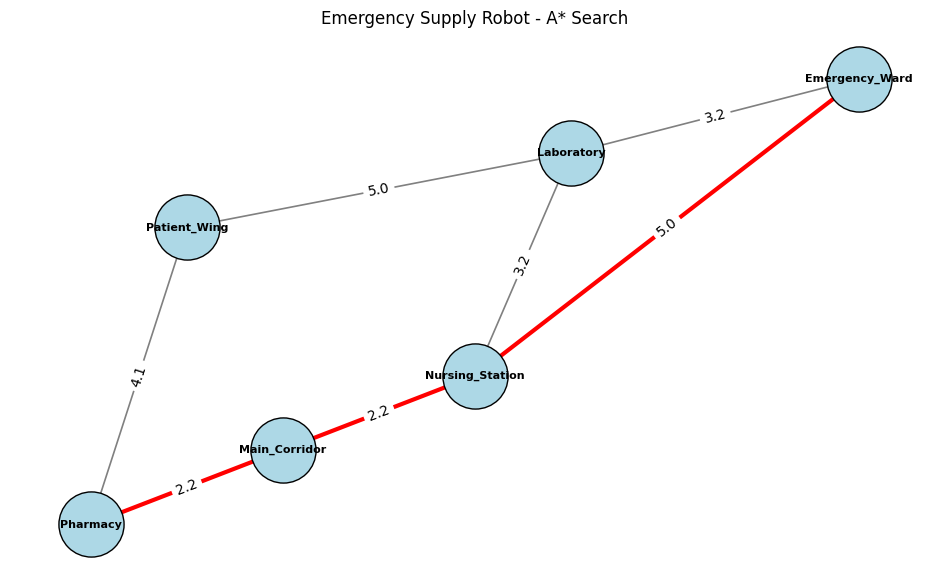

In [9]:
# 7. NetworkX visualization
G = nx.DiGraph()
for node, neighbors in hospital_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

pos = locations
path_edges = list(zip(path, path[1:]))
edge_colors = ["red" if edge in path_edges else "gray" for edge in G.edges]
edge_widths = [3 if edge in path_edges else 1.2 for edge in G.edges]

plt.figure(figsize=(12, 7))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=2200, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")
nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    width=edge_widths,
    arrows=True,
    arrowsize=20,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"))
plt.title("Emergency Supply Robot - A* Search")
plt.axis("off")
plt.show()

GBFS would primarily ask:

"Which node appears closest to the Emergency Ward?"

A* instead asks:

"Considering both the cost already travelled and the estimated remaining cost, which node has the lowest estimated total cost?"

#### Expansion order

This means:

In what order did the search algorithm remove/select nodes from the frontier and process them?

For example:

Expanded:
S → A → B → C → D → G

The algorithm may explore some nodes that are ultimately not part of the final route.

#### Solution path

This means:

Which nodes form the final route from start to goal?

For example:

Solution:
S → A → C → G

Here:

Expansion order:  S → A → B → C → D → G
Solution path:    S → A → C → G